## 1. Database Identification

**Selected Database:** Apollo 13 Flight Director Loop

**Description:** 
The recording captures the White Team shift led by Flight Director Gene Kranz during the Apollo 13 oxygen tank failure and subsequent crisis response. It features multiple flight controllers communicating across dedicated loops (EECOM, GNC, CAPCOM, etc.).

**Source:** [NASA Apollo 13 Flight Director Loop recording on YouTube](https://www.youtube.com/watch?v=KWfnY9cRXO4).

**Format:** Audio recording (`audio.m4a` in this project), resampled to 16 kHz mono for processing.

## 2. Exploratory Analysis

We will load a sample of the audio and examine its characteristics.

In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import IPython.display as ipd

# Path to the audio file
audio_path = 'audio.m4a'

# Load a 30-second sample for exploration
start_sec = 120 # Start 2 minutes in
duration_sec = 30
y, sr = librosa.load(audio_path, sr=16000, offset=start_sec, duration=duration_sec)

print(f"Sample Rate: {sr} Hz")
print(f"Duration: {len(y)/sr} seconds")
print(f"Audio Shape: {y.shape}")
print(f"Max Amplitude: {np.max(np.abs(y)):.4f}")
print(f"RMS Energy: {np.sqrt(np.mean(y**2)):.4f}")

/tmp/ipykernel_1716220/42691223.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=16000, offset=start_sec, duration=duration_sec)
/home/rdksupe/Desktop/HumanAI-TeamCommunication/.venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Sample Rate: 16000 Hz
Duration: 30.0 seconds
Audio Shape: (480000,)
Max Amplitude: 0.5118
RMS Energy: 0.0750


### 2.1 Waveform and Spectrogram Visualization

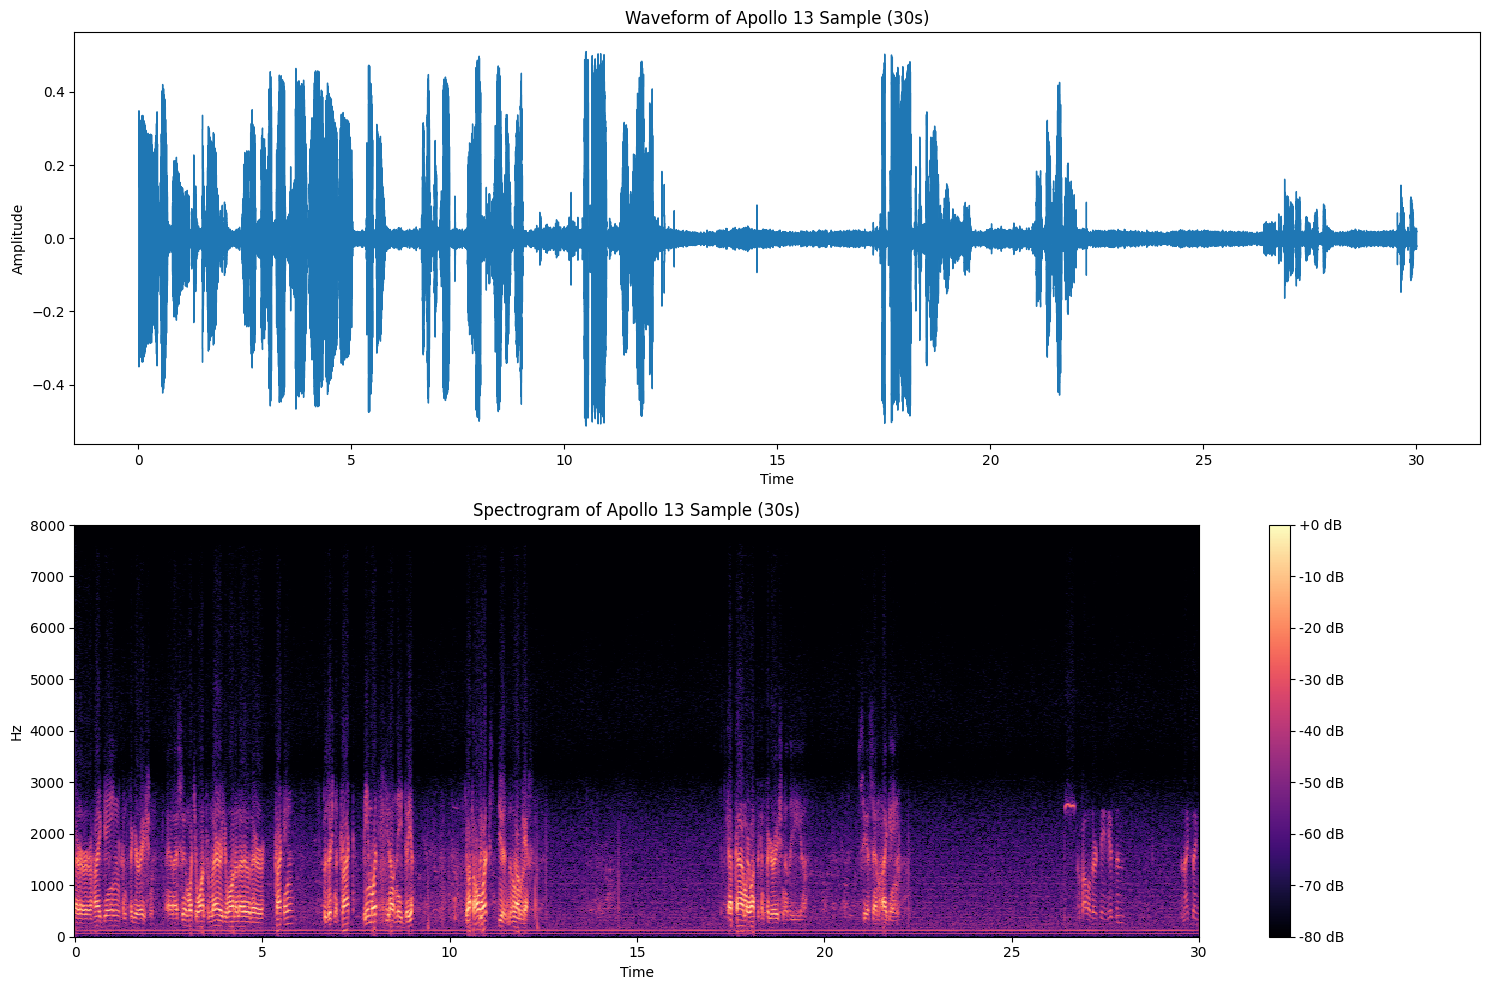

In [2]:
plt.figure(figsize=(15, 10))

# Waveform
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform of Apollo 13 Sample (30s)')
plt.ylabel('Amplitude')

# Spectrogram
plt.subplot(2, 1, 2)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz')
plt.title('Spectrogram of Apollo 13 Sample (30s)')
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

### 2.2 Audio Playback (Sample)

In [3]:
ipd.Audio(y, rate=sr)

## 3. Evaluation

### 3.1 How it will be used?

1. **Audio Enhancement Benchmarking**: The noisy nature of the recording (RF interference, static, VOX clipping) makes it an ideal real-world test case for denoising algorithms.
2. **ASR Robustness Testing**: Transcribing this audio with Whisper allows us to measure how much audio enhancement actually improves word recognition in high-noise team environments.
3. **Communication Analysis**: The multi-speaker interactions can be analyzed for team dynamics, leadership (Gene Kranz's role), and information flow under stress.

### 3.2 Why this data is the best option?

1. **Authenticity**: It captures genuine high-stakes team communication, not simulated or lab-recorded data.
2. **Representative Noise**: It contains various noise types (hiss, buzz, cross-talk, VOX clipping) that are common in mission-critical systems.
3. **Accessibility**: It is publicly available and out of copyright, ensuring full reproducibility without privacy issues.
4. **Complexity**: The multi-speaker, multi-channel nature mirrors modern complex team environments (e.g., control rooms, emergency response).
5. **Ground Truth availability**: Accurate transcripts exist from the "Apollo in Real Time" project, allowing for WER calculations.